In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [11]:
df = pd.read_excel("/Users/miguelangel/Documents/IISChallenge/IIS-Challenge/data/raw/BaseDatos_IISE_TO.xlsx")
df.head()

,Remisión,Unidad,Operador,Ruta,Fecha Inicio (Día),Fecha Fin (Día),Inicio (Hora),Fin (Hora),km,Litros,Rend,peso
0,P-110460,3157,DESGARENNIS ORTEGA CHRISTIAN,PUEBLA -CUAUTITLAN,2026-03-23,2026-03-23,04:59:00,16:46:00,346.4,137.0,2.528467,35.995
1,P-109685,3157,DESGARENNIS ORTEGA CHRISTIAN,PUEBLA -CUAUTITLAN,2026-02-18,2026-02-18,04:48:00,21:01:00,386.8,155.5,2.487460,34.761
2,P-109704,3077,APANECATL MORENO SAUL,PUEBLA -CUAUTITLAN,2026-02-18,2026-02-18,04:58:00,20:20:00,385.2,142.0,2.712676,34.778
3,P-109662,3158,PASTRANA CARIÑO FRANCISCO SAMUEL,PUEBLA -CUAUTITLAN,2026-02-17,2026-02-17,05:00:00,23:11:00,350.4,149.5,2.343813,34.803
4,P-109576,3158,PASTRANA CARIÑO FRANCISCO SAMUEL,PUEBLA -CUAUTITLAN,2026-02-16,2026-02-16,04:58:00,22:03:00,341.6,156.5,2.182748,34.828


In [12]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones: (75, 12)

Tipos de datos:
Remisión                         str
Unidad                         int64
Operador                         str
Ruta                             str
Fecha Inicio (Día)    datetime64[us]
Fecha Fin (Día)       datetime64[us]
Inicio (Hora)                 object
Fin (Hora)                    object
km                           float64
Litros                       float64
Rend                         float64
peso                         float64
dtype: object

Valores nulos por columna:
Remisión              0
Unidad                0
Operador              0
Ruta                  0
Fecha Inicio (Día)    0
Fecha Fin (Día)       0
Inicio (Hora)         0
Fin (Hora)            0
km                    0
Litros                0
Rend                  0
peso                  0
dtype: int64


Note: Inicio y Fin (Horas) - Are object, therefor i will need to convert them

In [13]:
df.describe()

,Unidad,Fecha Inicio (Día),Fecha Fin (Día),km,Litros,Rend,peso
count,75.000000,75,75,75.000000,75.000000,75.000000,75.000000
mean,3119.093333,2026-01-26 13:45:36,2026-01-26 14:24:00,349.185333,142.686667,2.457301,34.820587
min,2934.000000,2026-01-05 00:00:00,2026-01-05 00:00:00,328.300000,124.000000,2.032884,32.204000
25%,3097.500000,2026-01-16 00:00:00,2026-01-16 00:00:00,340.950000,136.250000,2.331183,34.744500
50%,3119.000000,2026-01-26 00:00:00,2026-01-26 00:00:00,345.700000,141.000000,2.478700,34.820000
75%,3158.000000,2026-02-04 00:00:00,2026-02-04 00:00:00,352.950000,147.750000,2.558439,34.926000
max,3163.000000,2026-03-23 00:00:00,2026-03-23 00:00:00,423.600000,185.500000,3.209091,35.995000
std,37.635942,NaN,NaN,15.508617,9.833332,0.186444,0.391709


In [17]:
df.nunique()

Remisión              74
Unidad                15
Operador              15
Ruta                   1
Fecha Inicio (Día)    32
Fecha Fin (Día)       33
Inicio (Hora)         30
Fin (Hora)            69
km                    70
Litros                46
Rend                  75
peso                  67
dtype: int64

In [18]:
print("Viajes por operador:")
print(df['Operador'].value_counts())
print("\nViajes por unidad:")
print(df['Unidad'].value_counts())

Viajes por operador:
Operador
SALAZAR ORTEGA EDGAR                  11
APANECATL MORENO SAUL                 10
BELLO CORONA JUAN CARLOS               8
CUEVAS ROMERO ALFONSO                  7
ARIAS MENDOZA LUIS ENRIQUE             7
PASTRANA CARIÑO FRANCISCO SAMUEL       6
ARELLANO ALBERTO IGNACIO               6
HERNANDEZ ZAVALA JESUS FABIAN          5
DESGARENNIS ORTEGA CHRISTIAN           4
DE JESUS GARCIA CONSTANTINO            4
GALINDO GARCIA FELIPE MANUEL           3
DEL ROSARIO LUNA ANTONIO ABAD          1
BARREDA DURAN SIMON OCTAVIO            1
BONILLA PALESTINA VICTOR ALEJANDRO     1
GUZMAN JULIAN ELIAS                    1
Name: count, dtype: int64

Viajes por unidad:
Unidad
3102    11
3077    10
3163     8
3162     7
3121     7
3158     6
3113     6
3119     5
3157     4
3093     4
3089     3
3091     1
2934     1
3122     1
3120     1
Name: count, dtype: int64


In [19]:
print("Combinaciones Operador-Unidad:")
print(df.groupby('Operador')['Unidad'].unique())

Combinaciones Operador-Unidad:
Operador
APANECATL MORENO SAUL                 [3077]
ARELLANO ALBERTO IGNACIO              [3113]
ARIAS MENDOZA LUIS ENRIQUE            [3121]
BARREDA DURAN SIMON OCTAVIO           [2934]
BELLO CORONA JUAN CARLOS              [3163]
BONILLA PALESTINA VICTOR ALEJANDRO    [3122]
CUEVAS ROMERO ALFONSO                 [3162]
DE JESUS GARCIA CONSTANTINO           [3093]
DEL ROSARIO LUNA ANTONIO ABAD         [3091]
DESGARENNIS ORTEGA CHRISTIAN          [3157]
GALINDO GARCIA FELIPE MANUEL          [3089]
GUZMAN JULIAN ELIAS                   [3120]
HERNANDEZ ZAVALA JESUS FABIAN         [3119]
PASTRANA CARIÑO FRANCISCO SAMUEL      [3158]
SALAZAR ORTEGA EDGAR                  [3102]
Name: Unidad, dtype: object


Note: This dataset contains perfect confounding. ()

## Distribución del Rendimiento (km/L)

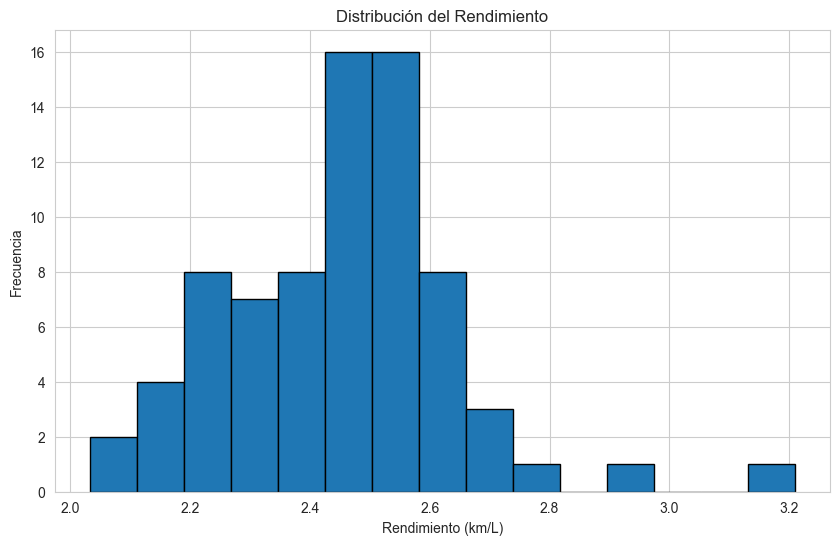

In [22]:
plt.hist(df['Rend'], bins=15, edgecolor='black')
plt.xlabel('Rendimiento (km/L)')
plt.ylabel('Frecuencia')
plt.title('Distribución del Rendimiento')
plt.show()

**Histograma:** la distribución se concentra entre 2.2 y 2.6 km/L, con una cola derecha - hay unos pocos viajes con rendimiento muy alto (3.0-3.2 km/L). Esos valores altos son outliers que vale la pena investigar: ¿quién los hizo y en qué condiciones? Quizás son los viajes de Arias Mendoza con la unidad 3121, que en el boxplot se ve que tiene un dato extremo arriba de 3.2.

## Boxplot de rendimiento por operador

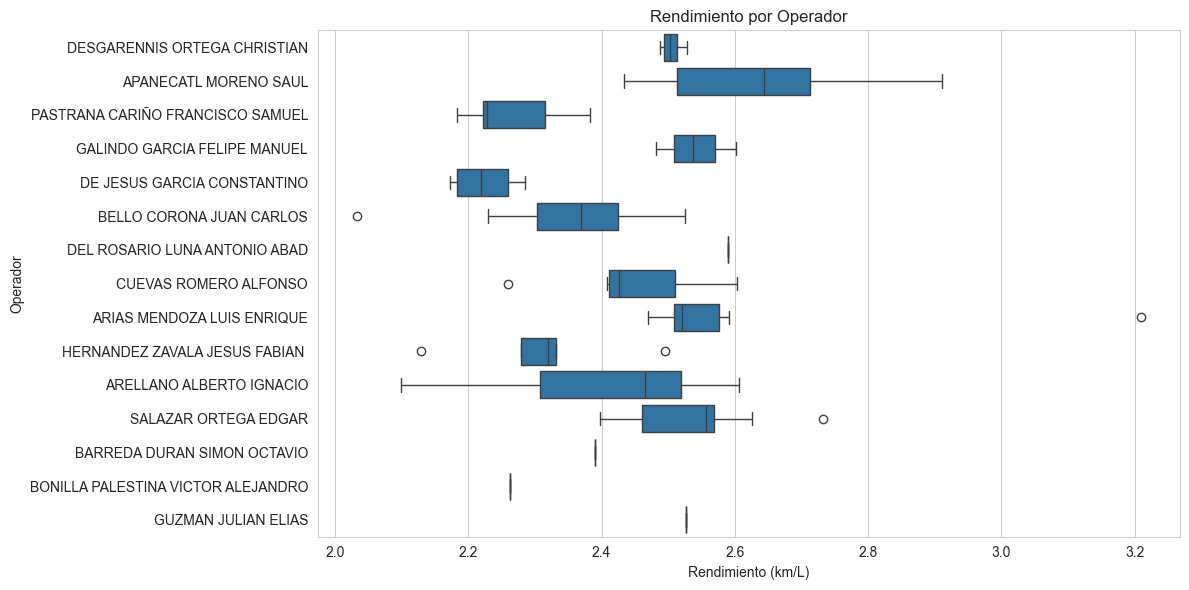

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Rend', y='Operador', data=df, orient='h')
plt.xlabel('Rendimiento (km/L)')
plt.title('Rendimiento por Operador')
plt.tight_layout()
plt.show()

**Boxplot:** Primero, los operadores con las cajas más altas (Desgarennis, Apanecatl, Arias) son los más eficientes. Segundo, Hernández Zavala y De Jesús García están consistentemente abajo de 2.3 km/L — son candidatos a entrenamiento. Tercero, Arellano y Bello Corona tienen cajas muy anchas, lo que significa que son inconsistentes: a veces manejan bien y a veces no. Los operadores con solo 1 viaje (Barreda, Bonilla, Guzmán, Del Rosario) son solo una línea — no puedes concluir nada de ellos.

## Scatter plot peso vs. rendimiento

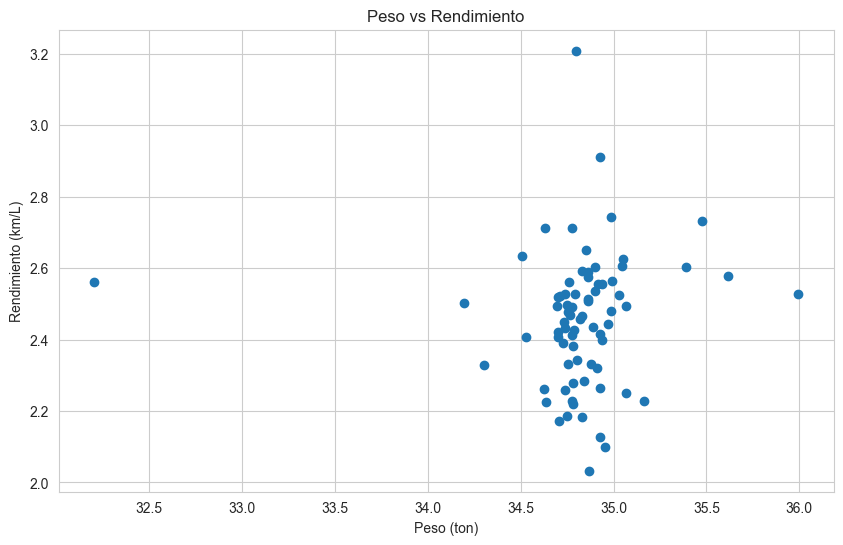

In [24]:
plt.scatter(df['peso'], df['Rend'])
plt.xlabel('Peso (ton)')
plt.ylabel('Rendimiento (km/L)')
plt.title('Peso vs Rendimiento')
plt.show()

**Scatter plot:** No hay relación clara entre peso y rendimiento.

<Axes: >

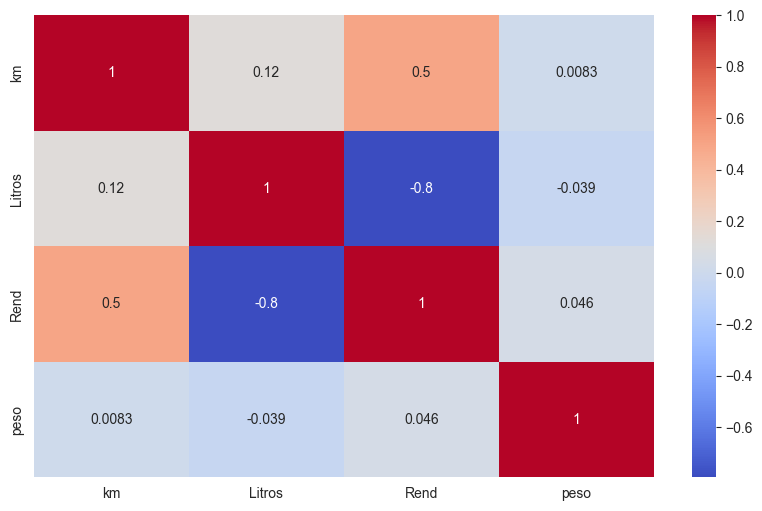

In [25]:
sns.heatmap(df[['km', 'Litros', 'Rend', 'peso']].corr(), annot=True, cmap='coolwarm')

**Descripción:** la variabilidad en consumo no se explica por peso ni por distancia. Se explica principalmente por quién maneja (y/o qué unidad usa).

## Scatter km vs. Litros:

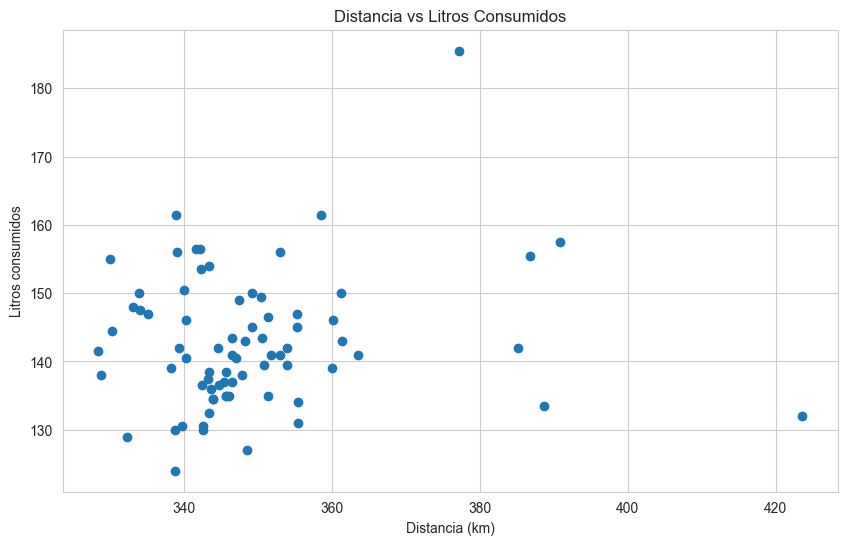

In [26]:
plt.scatter(df['km'], df['Litros'])
plt.xlabel('Distancia (km)')
plt.ylabel('Litros consumidos')
plt.title('Distancia vs Litros Consumidos')
plt.show()

## Rendimiento en el tiempo:

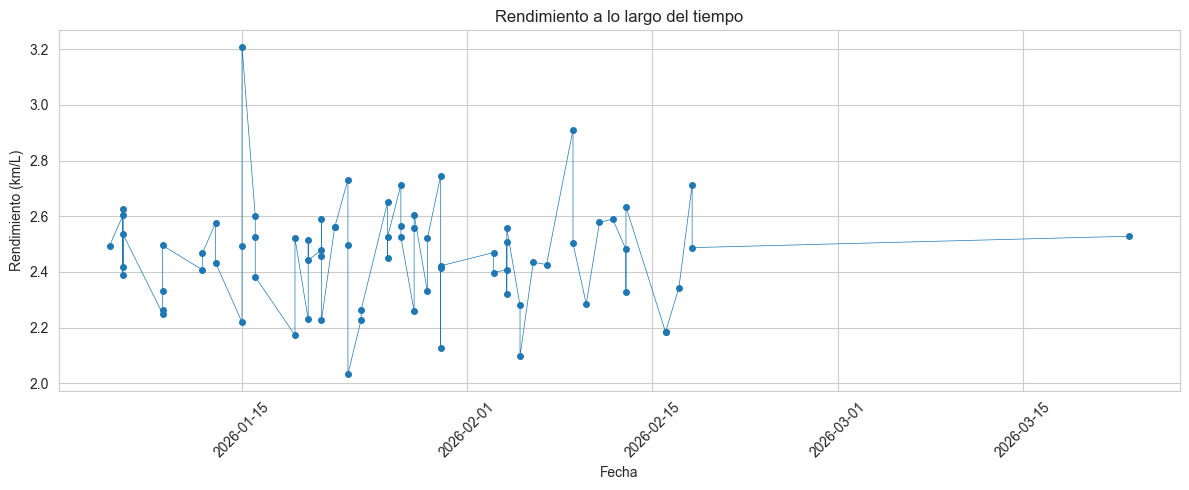

In [27]:
df_sorted = df.sort_values('Fecha Inicio (Día)')
plt.figure(figsize=(12, 5))
plt.plot(df_sorted['Fecha Inicio (Día)'], df_sorted['Rend'], marker='o', linewidth=0.5, markersize=4)
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (km/L)')
plt.title('Rendimiento a lo largo del tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Rendimiento en el tiempo:** no hay tendencia clara, ni mejora ni deterioro. Lo que sí se ve es que la mayor concentración de viajes está entre enero y mediados de febrero, y después hay muy pocos datos en marzo. La variabilidad es constante — el rendimiento sube y baja sin patrón temporal.

## Rendimiento promedio por operador

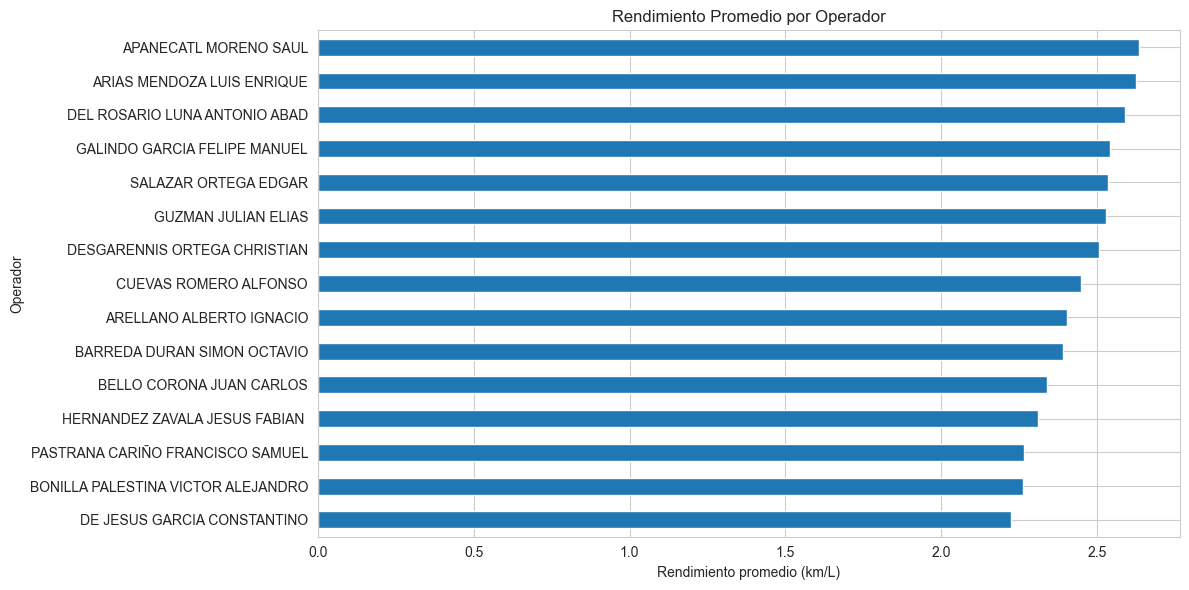

In [29]:
plt.figure(figsize=(12, 6))
df.groupby('Operador')['Rend'].mean().sort_values().plot(kind='barh')
plt.xlabel('Rendimiento promedio (km/L)')
plt.title('Rendimiento Promedio por Operador')
plt.tight_layout()
plt.show()

**Barras de rendimiento por operador:** La diferencia entre Apanecatl Moreno (~2.65 km/L) y De Jesús García (~2.15 km/L) es de medio km/L. Eso parece poco, pero en una ruta de 350 km redondos significa que De Jesús consume ~30 litros más por viaje. A $28/L, eso son $840 extra por viaje. Si hace 4 viajes al mes, son $3,360 mensuales desperdiciados solo en un operador.

## Hallazgos

El peso no explica la variabilidad porque es casi constante (~34.8 ton), la distancia tampoco la explica bien (correlación 0.12 con litros), el factor dominante es el operador/unidad con diferencias de hasta 30% en rendimiento entre el mejor y el peor, hay confusión perfecta entre operador y unidad (relación 1 a 1), y no hay tendencia temporal.